In [1]:
import gc
import zlib
import json
import hashlib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from scipy import ndimage
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any
from skimage import measure, morphology, segmentation


In [2]:
PROJECT_ROOT = Path(r"F:/AstraZeneca/project/chestCT/CHEST_CT_NSCLC")

LUNA_ROOT = PROJECT_ROOT / "data" / "raw" / "LUNA"

LUNA_ANNOTATIONS_PATH = LUNA_ROOT / "annotations.csv"
LUNA_CANDIDATES_PATH = LUNA_ROOT / "candidates.csv"
LUNA_CANDIDATES_V2_ZIP_PATH = LUNA_ROOT / "candidates_V2.zip"

# subset0.zip - subset9.zip
LUNA_SUBSET_ZIPS = sorted(
    LUNA_ROOT.glob("subset*.zip"),
    key=lambda x: int("".join(filter(str.isdigit, x.stem)) or -1)
)

# output
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
LUNA_TABLE_DIR = PROCESSED_DIR / "tables" / "luna16"
LUNA_FIGURE_DIR = PROCESSED_DIR / "figures" / "luna16"
LUNA_QC_FIGURE_DIR = LUNA_FIGURE_DIR / "preprocessing_qc"

# Optional full-volume output folder
LUNA_PREPROCESSED_VOLUME_DIR = PROCESSED_DIR / "luna16_preprocessed_volumes"

for p in [LUNA_TABLE_DIR, LUNA_FIGURE_DIR, LUNA_QC_FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LUNA_ROOT:", LUNA_ROOT)
print("LUNA_TABLE_DIR:", LUNA_TABLE_DIR)
print("LUNA_FIGURE_DIR:", LUNA_FIGURE_DIR)

PROJECT_ROOT: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC
LUNA_ROOT: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA
LUNA_TABLE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16
LUNA_FIGURE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\figures\luna16


In [3]:
# Preprocessing parameters
TARGET_SPACING_XYZ = np.array([1.0, 1.0, 1.0], dtype=np.float32)

HU_CLIP_MIN = -1000
HU_CLIP_MAX = 400

# Common operational threshold for lung air-like region
LUNG_THRESHOLD_HU = -320

# None means process all selected scans.
# Recommended first validation: 5, 10, or 20.
# Full run: None
MAX_SCANS_TO_PREPROCESS = 10

# If True, process scans that have nodule annotations first.
PROCESS_ONLY_SCANS_WITH_NODULES_FIRST = True

# Keep False if disk space is limited.
# True will save compressed preprocessed image and lung mask as .npz.
SAVE_FULL_PREPROCESSED_VOLUME = False

# Number of QC figures to save
MAX_QC_FIGURES = 20

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("TARGET_SPACING_XYZ:", TARGET_SPACING_XYZ)
print("MAX_SCANS_TO_PREPROCESS:", MAX_SCANS_TO_PREPROCESS)
print("SAVE_FULL_PREPROCESSED_VOLUME:", SAVE_FULL_PREPROCESSED_VOLUME)

TARGET_SPACING_XYZ: [1. 1. 1.]
MAX_SCANS_TO_PREPROCESS: 10
SAVE_FULL_PREPROCESSED_VOLUME: False


In [4]:
print("LUNA_ROOT exists:", LUNA_ROOT.exists(), LUNA_ROOT)

print("\nCSV files:")
print("annotations.csv exists:", LUNA_ANNOTATIONS_PATH.exists(), LUNA_ANNOTATIONS_PATH)
print("candidates.csv exists:", LUNA_CANDIDATES_PATH.exists(), LUNA_CANDIDATES_PATH)
print("candidates_V2.zip exists:", LUNA_CANDIDATES_V2_ZIP_PATH.exists(), LUNA_CANDIDATES_V2_ZIP_PATH)

print("\nSubset zip files:")
print("Number of subset zip files:", len(LUNA_SUBSET_ZIPS))
for z in LUNA_SUBSET_ZIPS:
    print(" -", z.name)

LUNA_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA

CSV files:
annotations.csv exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA\annotations.csv
candidates.csv exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA\candidates.csv
candidates_V2.zip exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LUNA\candidates_V2.zip

Subset zip files:
Number of subset zip files: 10
 - subset0.zip
 - subset1.zip
 - subset2.zip
 - subset3.zip
 - subset4.zip
 - subset5.zip
 - subset6.zip
 - subset7.zip
 - subset8.zip
 - subset9.zip


In [5]:
annotations = pd.read_csv(LUNA_ANNOTATIONS_PATH)
candidates = pd.read_csv(LUNA_CANDIDATES_PATH)

print("annotations shape:", annotations.shape)
display(annotations.head())

print("candidates shape:", candidates.shape)
display(candidates.head())

annotations shape: (1186, 5)


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


candidates shape: (551065, 5)


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [6]:
def read_csv_from_zip(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(".csv")]
        print("CSV files inside zip:", csv_files)

        if len(csv_files) == 0:
            raise FileNotFoundError(f"No CSV file found inside {zip_path}")

        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f)

    return df


if LUNA_CANDIDATES_V2_ZIP_PATH.exists():
    candidates_v2 = read_csv_from_zip(LUNA_CANDIDATES_V2_ZIP_PATH)
    print("candidates_v2 shape:", candidates_v2.shape)
    display(candidates_v2.head())
else:
    candidates_v2 = None
    print("candidates_V2.zip not found.")

CSV files inside zip: ['candidates_V2.csv']
candidates_v2 shape: (754975, 5)


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,68.420000,-74.480000,-288.700000,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-95.209361,-91.809406,-377.426350,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-24.766755,-120.379294,-273.361539,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-63.080000,-65.740000,-344.240000,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,52.946688,-92.688873,-241.067872,0


In [7]:
print("Annotation columns:")
print(annotations.columns.tolist())

print("\nMissing values:")
display(annotations.isna().sum())

print("\nTotal annotated nodules:", len(annotations))
print("Unique CT scans with annotated nodules:", annotations["seriesuid"].nunique())

print("\nNodule diameter statistics:")
display(annotations["diameter_mm"].describe())

annotation_stats = {
    "num_annotated_nodules": int(len(annotations)),
    "num_unique_scans_with_nodules": int(annotations["seriesuid"].nunique()),
    "diameter_mean_mm": float(annotations["diameter_mm"].mean()),
    "diameter_std_mm": float(annotations["diameter_mm"].std()),
    "diameter_min_mm": float(annotations["diameter_mm"].min()),
    "diameter_q25_mm": float(annotations["diameter_mm"].quantile(0.25)),
    "diameter_median_mm": float(annotations["diameter_mm"].median()),
    "diameter_q75_mm": float(annotations["diameter_mm"].quantile(0.75)),
    "diameter_max_mm": float(annotations["diameter_mm"].max()),
    "missing_values": annotations.isna().sum().to_dict()
}

with open(LUNA_TABLE_DIR / "annotation_stats.json", "w", encoding="utf-8") as f:
    json.dump(annotation_stats, f, indent=4)

annotation_stats

Annotation columns:
['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']

Missing values:


seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64


Total annotated nodules: 1186
Unique CT scans with annotated nodules: 601

Nodule diameter statistics:


count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64

{'num_annotated_nodules': 1186,
 'num_unique_scans_with_nodules': 601,
 'diameter_mean_mm': 8.306527315553964,
 'diameter_std_mm': 4.762032807179365,
 'diameter_min_mm': 3.253443196,
 'diameter_q25_mm': 5.1071767445,
 'diameter_median_mm': 6.433600479000001,
 'diameter_q75_mm': 9.696301457499999,
 'diameter_max_mm': 32.27003025,
 'missing_values': {'seriesuid': 0,
  'coordX': 0,
  'coordY': 0,
  'coordZ': 0,
  'diameter_mm': 0}}

In [8]:
def diameter_group(d):
    if d < 6:
        return "<6mm"
    elif d < 8:
        return "6-8mm"
    elif d < 15:
        return "8-15mm"
    else:
        return ">=15mm"


annotations["diameter_group"] = annotations["diameter_mm"].apply(diameter_group)

diameter_group_summary = (
    annotations["diameter_group"]
    .value_counts()
    .rename_axis("diameter_group")
    .reset_index(name="count")
)

diameter_group_summary["percentage"] = (
    diameter_group_summary["count"] / len(annotations) * 100
).round(2)

display(diameter_group_summary)

diameter_group_summary.to_csv(
    LUNA_TABLE_DIR / "diameter_group_summary.csv",
    index=False
)

,diameter_group,count,percentage
0,<6mm,502,42.33
1,8-15mm,281,23.69
2,6-8mm,276,23.27
3,>=15mm,127,10.71


In [9]:
nodules_per_scan = (
    annotations.groupby("seriesuid")
    .size()
    .reset_index(name="nodule_count")
    .sort_values("nodule_count", ascending=False)
)

display(nodules_per_scan.head(20))

print("Nodules per scan statistics:")
display(nodules_per_scan["nodule_count"].describe())

nodules_per_scan.to_csv(
    LUNA_TABLE_DIR / "nodules_per_scan.csv",
    index=False
)

,seriesuid,nodule_count
142,1.3.6.1.4.1.14519.5.2.1.6279.6001.176030616406...,12
441,1.3.6.1.4.1.14519.5.2.1.6279.6001.328789598898...,9
186,1.3.6.1.4.1.14519.5.2.1.6279.6001.195557219224...,9
201,1.3.6.1.4.1.14519.5.2.1.6279.6001.202187810895...,9
239,1.3.6.1.4.1.14519.5.2.1.6279.6001.219428004988...,9
275,1.3.6.1.4.1.14519.5.2.1.6279.6001.239358021703...,8
21,1.3.6.1.4.1.14519.5.2.1.6279.6001.112767175295...,8
408,1.3.6.1.4.1.14519.5.2.1.6279.6001.309955999522...,7
581,1.3.6.1.4.1.14519.5.2.1.6279.6001.910435939545...,7
360,1.3.6.1.4.1.14519.5.2.1.6279.6001.280072876841...,7


Nodules per scan statistics:


count    601.000000
mean       1.973378
std        1.483000
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       12.000000
Name: nodule_count, dtype: float64

In [10]:
candidate_class_summary = (
    candidates["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

candidate_class_summary["percentage"] = (
    candidate_class_summary["count"] / len(candidates) * 100
).round(4)

display(candidate_class_summary)

candidate_class_summary.to_csv(
    LUNA_TABLE_DIR / "candidate_class_summary.csv",
    index=False
)

,class,count,percentage
0,0,549714,99.7548
1,1,1351,0.2452


In [11]:
subset_zip_summary = []

for zip_path in LUNA_SUBSET_ZIPS:
    with zipfile.ZipFile(zip_path, "r") as z:
        names = z.namelist()

        mhd_files = [n for n in names if n.lower().endswith(".mhd")]
        raw_files = [n for n in names if n.lower().endswith(".raw")]
        zraw_files = [n for n in names if n.lower().endswith(".zraw")]

        subset_zip_summary.append({
            "zip_file": zip_path.name,
            "num_mhd": len(mhd_files),
            "num_raw": len(raw_files),
            "num_zraw": len(zraw_files),
            "total_files": len(names)
        })

subset_zip_df = pd.DataFrame(subset_zip_summary)
display(subset_zip_df)

subset_zip_df.to_csv(
    LUNA_TABLE_DIR / "subset_zip_file_counts.csv",
    index=False
)

,zip_file,num_mhd,num_raw,num_zraw,total_files
0,subset0.zip,89,89,0,178
1,subset1.zip,89,89,0,178
2,subset2.zip,89,89,0,178
3,subset3.zip,89,89,0,178
4,subset4.zip,89,89,0,178
5,subset5.zip,89,89,0,178
6,subset6.zip,89,89,0,178
7,subset7.zip,89,89,0,178
8,subset8.zip,88,88,0,176
9,subset9.zip,88,88,0,176


In [12]:
def parse_number_list(value: str, dtype=float):
    return [dtype(x) for x in value.replace(",", " ").split()]


def parse_mhd_header_from_zip(zip_path: Path, mhd_name: str):
    with zipfile.ZipFile(zip_path, "r") as z:
        text = z.read(mhd_name).decode("utf-8", errors="ignore")

    header = {}

    for line in text.splitlines():
        line = line.strip()
        if "=" in line:
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    return header


def build_luna_metadata_from_zips(subset_zips):
    metadata_rows = []

    for subset_zip in tqdm(subset_zips, desc="Reading .mhd headers"):
        with zipfile.ZipFile(subset_zip, "r") as z:
            mhd_names = [n for n in z.namelist() if n.lower().endswith(".mhd")]

        for mhd_name in mhd_names:
            header = parse_mhd_header_from_zip(subset_zip, mhd_name)

            dim_size = parse_number_list(header.get("DimSize", "0 0 0"), int)
            spacing = parse_number_list(header.get("ElementSpacing", "0 0 0"), float)

            origin_text = header.get("Offset", header.get("Position", "0 0 0"))
            origin = parse_number_list(origin_text, float)

            transform_text = header.get("TransformMatrix", "1 0 0 0 1 0 0 0 1")
            transform = parse_number_list(transform_text, float)

            metadata_rows.append({
                "seriesuid": Path(mhd_name).stem,
                "subset_zip": subset_zip.name,
                "mhd_name": mhd_name,
                "raw_file": header.get("ElementDataFile"),

                "size_x": dim_size[0],
                "size_y": dim_size[1],
                "size_z": dim_size[2],

                "spacing_x": spacing[0],
                "spacing_y": spacing[1],
                "spacing_z": spacing[2],

                "origin_x": origin[0],
                "origin_y": origin[1],
                "origin_z": origin[2],

                "transform_00": transform[0],
                "transform_01": transform[1],
                "transform_02": transform[2],
                "transform_10": transform[3],
                "transform_11": transform[4],
                "transform_12": transform[5],
                "transform_20": transform[6],
                "transform_21": transform[7],
                "transform_22": transform[8],

                "element_type": header.get("ElementType"),
                "compressed_data": header.get("CompressedData", "False"),
                "byte_order_msb": header.get("ElementByteOrderMSB", "False"),
            })

    return pd.DataFrame(metadata_rows)


metadata_df = build_luna_metadata_from_zips(LUNA_SUBSET_ZIPS)

print("Total CT scans found from zip metadata:", len(metadata_df))
display(metadata_df.head())

metadata_df.to_csv(
    LUNA_TABLE_DIR / "ct_metadata_from_zip.csv",
    index=False
)

Reading .mhd headers: 100%|██████████| 10/10 [00:02<00:00,  3.76it/s]

Total CT scans found from zip metadata: 888


,seriesuid,subset_zip,mhd_name,raw_file,size_x,size_y,size_z,spacing_x,spacing_y,spacing_z,...,transform_02,transform_10,transform_11,transform_12,transform_20,transform_21,transform_22,element_type,compressed_data,byte_order_msb
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1057...,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031...,512,512,121,0.761719,0.761719,2.500,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1081...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,512,512,119,0.742188,0.742188,2.500,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1090...,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,512,512,161,0.548828,0.548828,1.250,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1111...,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,512,512,538,0.742188,0.742188,0.625,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,subset0.zip,subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.1227...,1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896...,512,512,124,0.615234,0.615234,2.500,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,MET_SHORT,False,False


In [13]:
print("Spacing statistics:")
display(metadata_df[["spacing_x", "spacing_y", "spacing_z"]].describe())

print("CT size statistics:")
display(metadata_df[["size_x", "size_y", "size_z"]].describe())

Spacing statistics:


,spacing_x,spacing_y,spacing_z
count,888.000000,888.000000,888.000000
mean,0.689530,0.689530,1.569538
std,0.084574,0.084574,0.725174
min,0.460938,0.460938,0.450000
25%,0.625000,0.625000,1.000000
50%,0.703125,0.703125,1.250000
75%,0.742188,0.742188,2.500000
max,0.976562,0.976562,2.500000


CT size statistics:


,size_x,size_y,size_z
count,888.0,888.0,888.000000
mean,512.0,512.0,255.884009
std,0.0,0.0,133.761188
min,512.0,512.0,95.000000
25%,512.0,512.0,137.750000
50%,512.0,512.0,237.500000
75%,512.0,512.0,305.000000
max,512.0,512.0,764.000000


In [14]:
ct_seriesuids = set(metadata_df["seriesuid"])
annotation_seriesuids = set(annotations["seriesuid"])

missing_ct_for_annotations = sorted(annotation_seriesuids - ct_seriesuids)
ct_without_annotations = sorted(ct_seriesuids - annotation_seriesuids)

matching_summary = {
    "ct_scans_found_in_subset_zips": int(len(ct_seriesuids)),
    "scans_with_annotations": int(len(annotation_seriesuids)),
    "annotations_without_matching_ct": int(len(missing_ct_for_annotations)),
    "ct_scans_without_annotated_nodules": int(len(ct_without_annotations)),
}

print(json.dumps(matching_summary, indent=4))

with open(LUNA_TABLE_DIR / "matching_summary.json", "w", encoding="utf-8") as f:
    json.dump(matching_summary, f, indent=4)

pd.DataFrame({"seriesuid": missing_ct_for_annotations}).to_csv(
    LUNA_TABLE_DIR / "missing_ct_for_annotations.csv",
    index=False
)

pd.DataFrame({"seriesuid": ct_without_annotations}).to_csv(
    LUNA_TABLE_DIR / "ct_without_annotations.csv",
    index=False
)

{
    "ct_scans_found_in_subset_zips": 888,
    "scans_with_annotations": 601,
    "annotations_without_matching_ct": 0,
    "ct_scans_without_annotated_nodules": 287
}


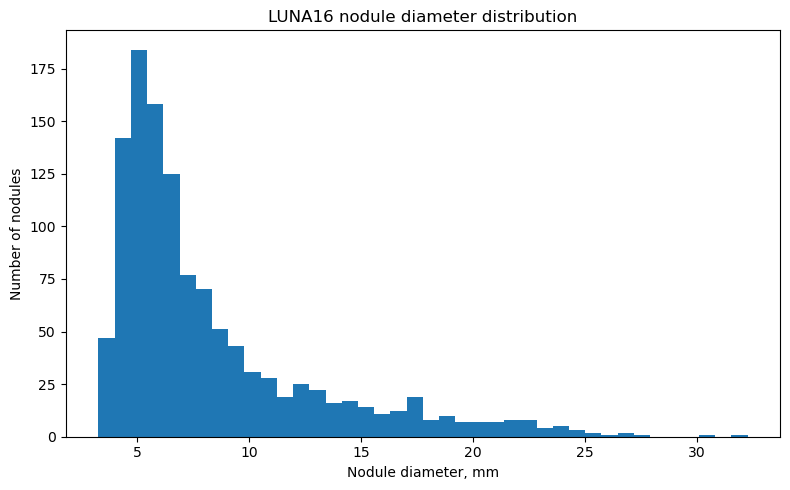

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(annotations["diameter_mm"], bins=40)
plt.xlabel("Nodule diameter, mm")
plt.ylabel("Number of nodules")
plt.title("LUNA16 nodule diameter distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "nodule_diameter_distribution.png", dpi=300)
plt.show()

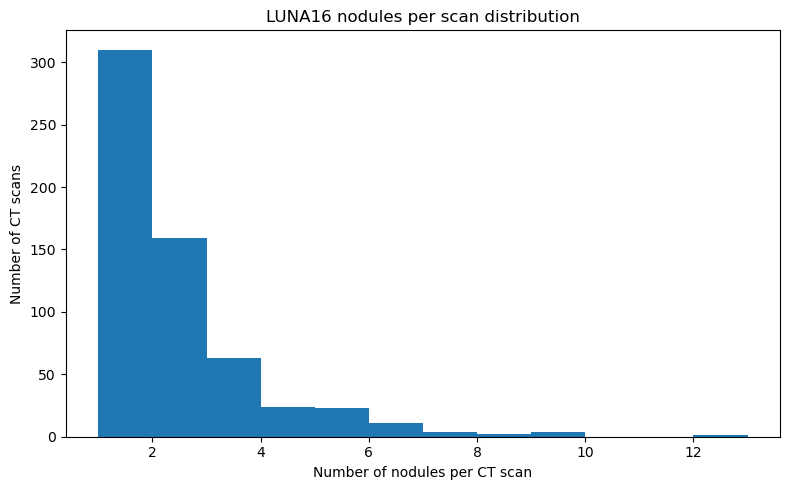

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(
    nodules_per_scan["nodule_count"],
    bins=range(1, int(nodules_per_scan["nodule_count"].max()) + 2)
)
plt.xlabel("Number of nodules per CT scan")
plt.ylabel("Number of CT scans")
plt.title("LUNA16 nodules per scan distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "nodules_per_scan_distribution.png", dpi=300)
plt.show()

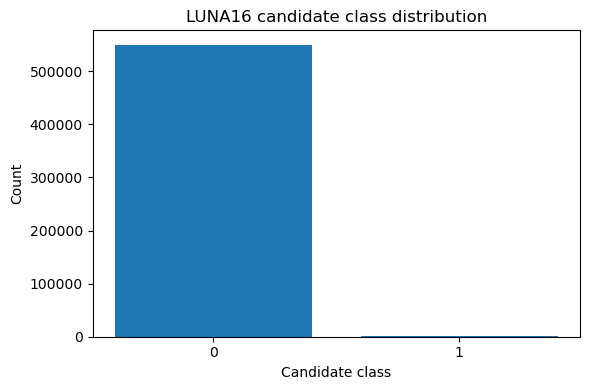

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(candidate_class_summary["class"].astype(str), candidate_class_summary["count"])
plt.xlabel("Candidate class")
plt.ylabel("Count")
plt.title("LUNA16 candidate class distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "candidate_class_distribution.png", dpi=300)
plt.show()

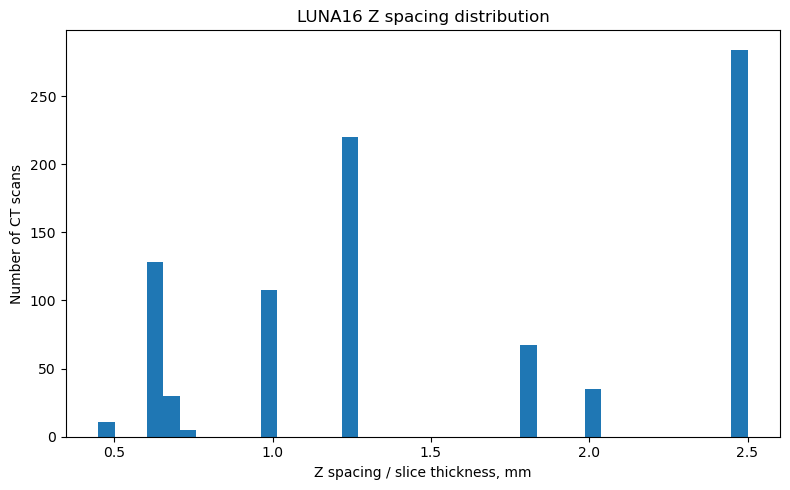

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(metadata_df["spacing_z"], bins=40)
plt.xlabel("Z spacing / slice thickness, mm")
plt.ylabel("Number of CT scans")
plt.title("LUNA16 Z spacing distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "z_spacing_distribution.png", dpi=300)
plt.show()

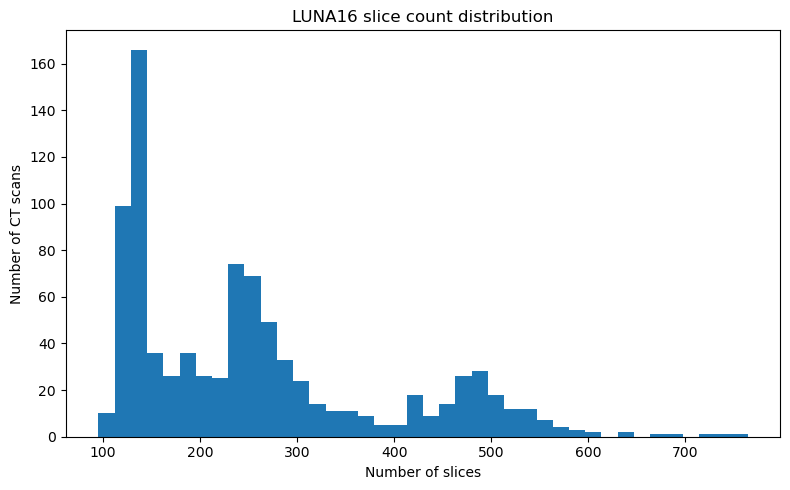

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(metadata_df["size_z"], bins=40)
plt.xlabel("Number of slices")
plt.ylabel("Number of CT scans")
plt.title("LUNA16 slice count distribution")
plt.tight_layout()
plt.savefig(LUNA_FIGURE_DIR / "slice_count_distribution.png", dpi=300)
plt.show()

In [20]:
basic_report_path = LUNA_TABLE_DIR / "luna16_basic_eda_report.md"

with open(basic_report_path, "w", encoding="utf-8") as f:
    f.write("# LUNA16 Basic EDA Report\n\n")

    f.write("## File audit\n\n")
    f.write(f"- Number of subset zip files: {len(subset_zip_df)}\n")
    f.write(f"- CT scans found from .mhd metadata: {len(metadata_df)}\n")
    f.write(f"- Annotation rows: {len(annotations)}\n")
    f.write(f"- Candidate rows: {len(candidates)}\n\n")

    f.write("## Annotation statistics\n\n")
    f.write(f"- Unique scans with annotated nodules: {annotations['seriesuid'].nunique()}\n")
    f.write(f"- Total annotated nodules: {len(annotations)}\n")
    f.write(f"- Mean nodule diameter: {annotations['diameter_mm'].mean():.2f} mm\n")
    f.write(f"- Median nodule diameter: {annotations['diameter_mm'].median():.2f} mm\n")
    f.write(f"- Min nodule diameter: {annotations['diameter_mm'].min():.2f} mm\n")
    f.write(f"- Max nodule diameter: {annotations['diameter_mm'].max():.2f} mm\n\n")

    f.write("## Diameter group summary\n\n")
    f.write(diameter_group_summary.to_csv(index=False))
    f.write("\n")

    f.write("## Candidate class distribution\n\n")
    f.write(candidate_class_summary.to_csv(index=False))
    f.write("\n")

    f.write("## CT metadata summary\n\n")
    f.write(f"- Mean z spacing: {metadata_df['spacing_z'].mean():.3f} mm\n")
    f.write(f"- Median z spacing: {metadata_df['spacing_z'].median():.3f} mm\n")
    f.write(f"- Mean number of slices: {metadata_df['size_z'].mean():.2f}\n")
    f.write(f"- Median number of slices: {metadata_df['size_z'].median():.2f}\n\n")

    f.write("## Matching check\n\n")
    for k, v in matching_summary.items():
        f.write(f"- {k}: {v}\n")

print("Saved:", basic_report_path)

Saved: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\luna16\luna16_basic_eda_report.md
